# 🌍 Projet : Prédiction de la Qualité de l'Air dans les Villes Marocaines

---

## 📋 Sommaire

1. [Introduction](#introduction)
2. [Collecte des Données](#collecte-des-données)
3. [Préparation des Données](#préparation-des-données)
4. [Analyse Exploratoire](#analyse-exploratoire)
5. [Modèles Centralisés](#modèles-centralisés)
6. [Apprentissage Fédéré](#apprentissage-fédéré)
7. [Conclusion](#conclusion)

---


## 1. Introduction

### 🎯 Objectif du Projet

Prédire la qualité de l'air (PM2.5 et AQI) dans les villes marocaines à partir de données météo et de pollution, en utilisant des approches centralisées et fédérées.

### 🏙️ Villes Étudiées

- Casablanca, Rabat, Marrakech, Fès, Tanger, Agadir

### 📊 Données Collectées

- **Période** : 25 avril - 9 mai 2026 (14 jours)
- **Fréquence** : Horaire (168 cycles)
- **Volume** : 996 enregistrements
- **Variables** : Température, humidité, pression, vent, PM2.5, PM10, NO₂, O₃, SO₂, CO, AQI

---


## 2. Collecte des Données

### 🔧 Script de Collecte (`collector.py`)

```python
# Extrait du code de collecte
def fetch_city_data(self, city_name, lat, lon):
    weather_url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={self.api_key}&units=metric"
    air_url = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={lat}&lon={lon}&appid={self.api_key}"
    
    # Récupération des données météo
    weather_response = self.session.get(weather_url, timeout=REQUEST_TIMEOUT)
    weather_data = weather_response.json()
    
    # Récupération des données de qualité de l'air
    air_response = self.session.get(air_url, timeout=REQUEST_TIMEOUT)
    air_data = air_response.json()
    
    # Construction de l'enregistrement
    record = {
        "timestamp": datetime.now().isoformat(),
        "city": city_name,
        "temp": weather_data["main"]["temp"],
        "humidity": weather_data["main"]["humidity"],
        "pressure": weather_data["main"]["pressure"],
        "wind_speed": weather_data["wind"]["speed"],
        "aqi": air_data["list"][0]["main"]["aqi"],
        "pm2_5": air_data["list"][0]["components"]["pm2_5"],
        "pm10": air_data["list"][0]["components"]["pm10"],
        "no2": air_data["list"][0]["components"]["no2"],
        "o3": air_data["list"][0]["components"]["o3"]
    }
    return record
```

### Résultats de la Collecte
Indicateur	            Valeur
Cycles prévus	        168
Enregistrements bruts	996
Doublons supprimés	    3
Valeurs interpolées	    39
Enregistrements finaux	996
Taux de complétude	    100%

---

In [30]:
# Cellule 1 : Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 3. Préparation des Données

In [31]:
# Cellule 2 : Chargement des données
df = pd.read_csv('../data/processed/air_quality_clean.csv')
df_scaled = pd.read_csv('../data/processed/air_quality_scaled.csv')

print(f"✅ Données chargées : {len(df)} enregistrements")
print(f"✅ Colonnes : {list(df.columns)}")

✅ Données chargées : 996 enregistrements
✅ Colonnes : ['cycle_index', 'city', 'timestamp', 'lat', 'lon', 'temp', 'feels_like', 'humidity', 'pressure', 'wind_speed', 'wind_deg', 'clouds', 'weather_main', 'weather_description', 'aqi', 'pm2_5', 'pm10', 'no2', 'o3', 'so2', 'co', 'hour', 'day_of_week', 'day_of_month', 'month', 'city_encoded']


### 📊 Résumé des Données

In [32]:
# Cellule 3 : Aperçu des données
print("📋 Aperçu des données :")
df.head()

📋 Aperçu des données :


,cycle_index,city,timestamp,lat,lon,temp,feels_like,humidity,pressure,wind_speed,...,pm10,no2,o3,so2,co,hour,day_of_week,day_of_month,month,city_encoded
0,0,Agadir,2026-04-25 23:31:05.569939,30.4278,-9.5981,17.06,17.07,86.0,1010.0,5.81,...,17.76,0.30,103.89,0.98,115.77,23.0,5.0,25.0,4.0,0
1,0,Casablanca,2026-04-25 23:30:49.327951,33.5731,-7.5898,17.89,18.03,88.0,1014.0,2.06,...,15.59,1.87,102.31,3.43,116.73,23.0,5.0,25.0,4.0,1
2,0,Fes,2026-04-25 23:30:59.033251,34.0181,-5.0078,14.95,14.96,94.0,1013.0,1.54,...,4.81,1.41,60.17,0.24,98.77,23.0,5.0,25.0,4.0,2
3,0,Marrakech,2026-04-25 23:30:55.811733,31.6295,-7.9811,19.98,19.81,68.0,1012.0,4.63,...,14.95,1.80,79.55,0.59,106.71,23.0,5.0,25.0,4.0,3
4,0,Rabat,2026-04-25 23:30:52.557303,34.0209,-6.8416,17.37,17.77,100.0,1013.0,2.06,...,15.19,2.35,100.55,3.27,119.22,23.0,5.0,25.0,4.0,4


In [33]:
# Cellule 4 : Statistiques descriptives
print("📊 Statistiques descriptives :")
df.describe()

📊 Statistiques descriptives :


,cycle_index,lat,lon,temp,feels_like,humidity,pressure,wind_speed,wind_deg,clouds,...,pm10,no2,o3,so2,co,hour,day_of_week,day_of_month,month,city_encoded
count,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000,...,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000
mean,83.716867,33.238150,-7.142067,19.500115,19.314885,69.272088,1013.336847,3.231561,187.706325,49.985944,...,10.640241,1.265889,92.179804,1.785793,108.896195,14.555891,2.881168,13.362538,4.628399,2.500000
std,48.742108,1.741384,1.489201,3.131518,3.217046,13.579739,3.295991,2.056294,129.631245,29.361237,...,7.571708,1.026354,15.542123,1.594608,7.897813,6.412703,1.866924,11.435706,0.482747,1.708683
min,0.000000,30.427800,-9.598100,9.370000,9.370000,33.000000,1005.000000,0.000000,0.000000,0.000000,...,2.220000,0.110000,28.990000,0.050000,88.880000,0.000000,0.000000,1.000000,4.000000,0.000000
25%,41.000000,31.629500,-7.981100,17.370000,17.170000,60.000000,1011.000000,2.060000,50.000000,40.000000,...,5.620000,0.430000,84.132500,0.540000,103.580000,11.000000,1.000000,4.000000,4.000000,1.000000
50%,84.500000,33.795600,-7.215700,19.020000,19.035000,68.000000,1013.000000,3.090000,247.000000,40.000000,...,8.445000,0.980000,94.795000,1.110000,108.910000,16.000000,3.000000,7.000000,5.000000,2.500000
75%,126.000000,34.020900,-5.834000,21.370000,21.207500,77.000000,1016.000000,4.120000,300.000000,75.000000,...,13.222500,1.870000,102.750000,3.132500,114.692500,20.000000,4.000000,27.000000,5.000000,4.000000
max,167.000000,35.759500,-5.007800,30.980000,30.480000,100.000000,1020.000000,14.920000,360.000000,100.000000,...,56.360000,6.450000,121.310000,6.960000,130.040000,23.000000,6.000000,30.000000,5.000000,5.000000


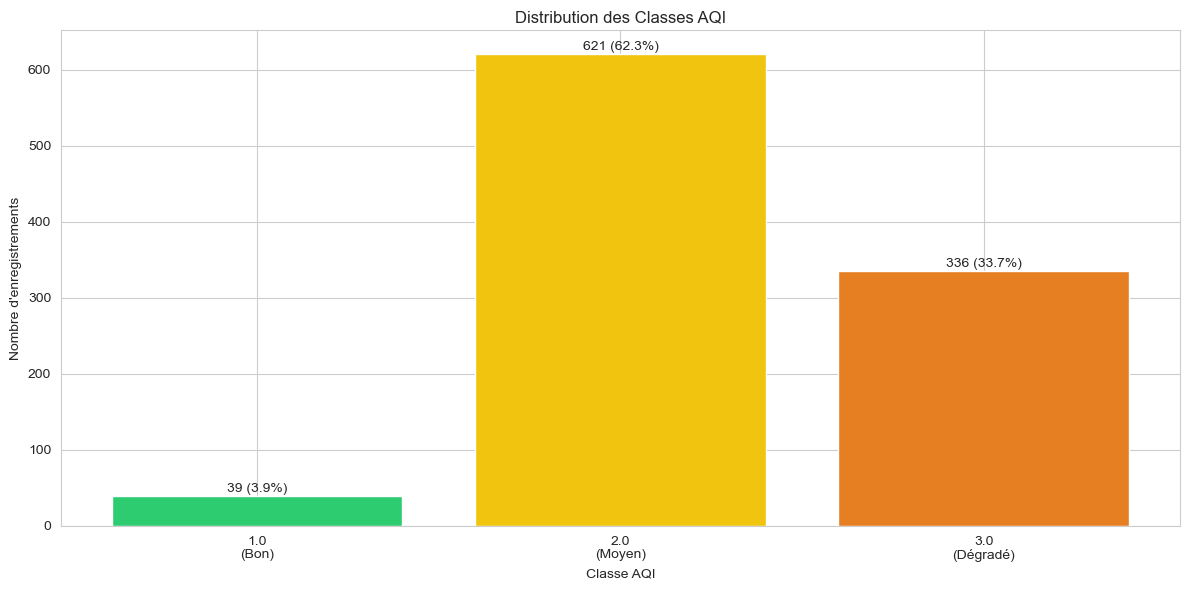

In [ ]:
# Cellule 5 : Distribution des classes AQI
aqi_counts = df['aqi'].value_counts().sort_index() #Comptage des classes AQI
aqi_names = {1: 'Bon', 2: 'Moyen', 3: 'Dégradé', 4: 'Mauvais', 5: 'Très mauvais'}

fig, ax = plt.subplots()
colors = ['#2ecc71', '#f1c40f', '#e67e22']
bars = ax.bar(aqi_counts.index, aqi_counts.values, color=colors)
ax.set_xticks(aqi_counts.index)
ax.set_xticklabels([f"{k}\n({aqi_names[k]})" for k in aqi_counts.index])
ax.set_xlabel('Classe AQI')
ax.set_ylabel('Nombre d\'enregistrements')
ax.set_title('Distribution des Classes AQI')
for bar, count in zip(bars, aqi_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
            f'{count} ({count/len(df)*100:.1f}%)', ha='center')
plt.tight_layout()
plt.show()

## 4. Analyse Exploratoire

### 🔍 Évolution Temporelle des PM2.5

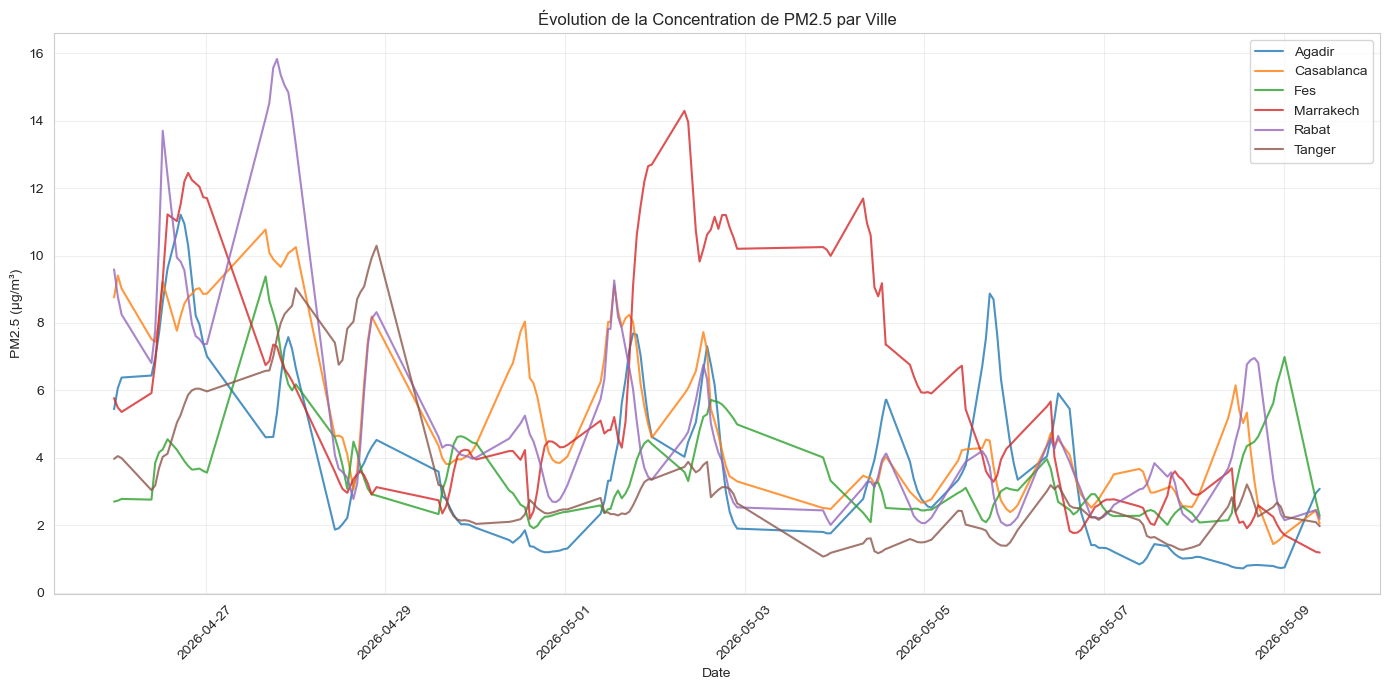

In [35]:
# Cellule 6 : Séries temporelles des PM2.5
df['timestamp'] = pd.to_datetime(df['timestamp'])
df_sorted = df.sort_values('timestamp')

fig, ax = plt.subplots(figsize=(14, 7))
for city in df['city'].unique():
    city_data = df_sorted[df_sorted['city'] == city]
    ax.plot(city_data['timestamp'], city_data['pm2_5'], 
            label=city, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('Évolution de la Concentration de PM2.5 par Ville')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📈 Matrice de Corrélation


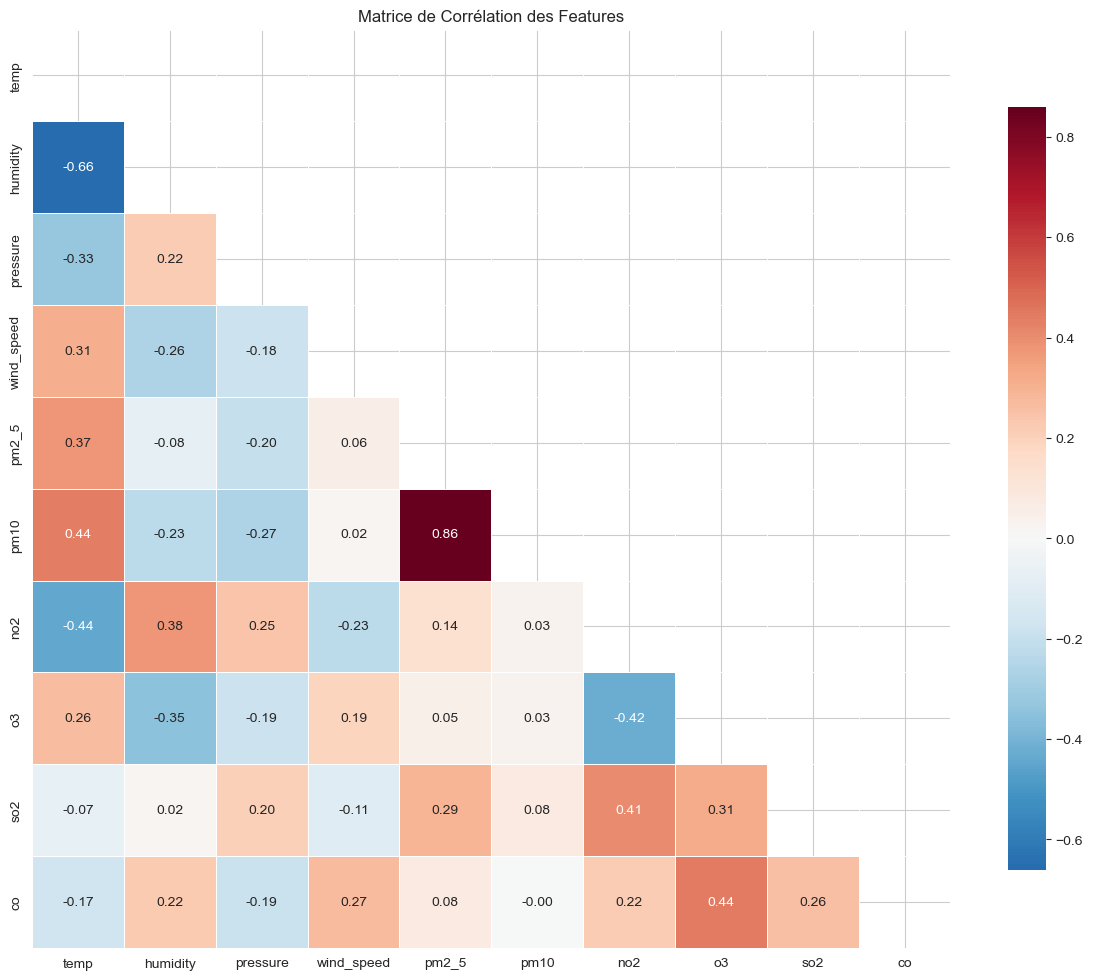

In [36]:
# Cellule 7 : Corrélations entre variables
features_corr = ['temp', 'humidity', 'pressure', 'wind_speed', 
                 'pm2_5', 'pm10', 'no2', 'o3', 'so2', 'co']

corr_matrix = df[features_corr].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Corrélation des Features')
plt.tight_layout()
plt.show()

### 🏙️ Distribution des PM2.5 par Ville

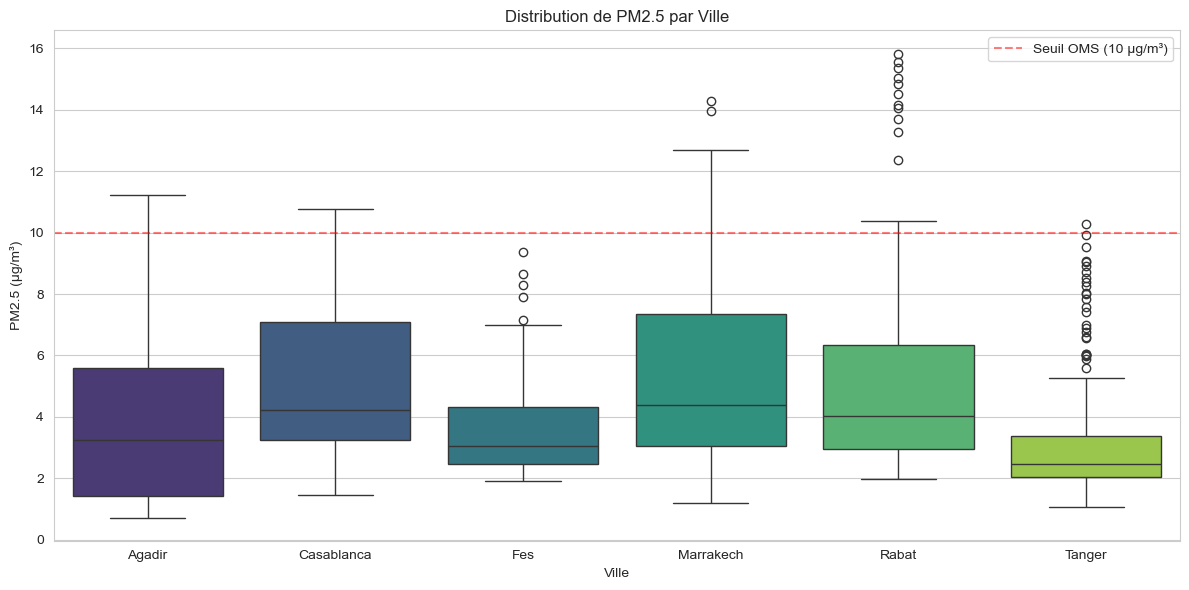

In [37]:
# Cellule 8 : Boxplots par ville
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='city', y='pm2_5', palette='viridis')
ax.set_xlabel('Ville')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('Distribution de PM2.5 par Ville')
ax.axhline(y=10, color='red', linestyle='--', alpha=0.5, label='Seuil OMS (10 µg/m³)')
ax.legend()
plt.tight_layout()
plt.show()

## Modèles Centralisés
### 5.1 Régression - Prédiction de PM2.5

In [38]:
# Cellule 9 : Préparation des données pour la régression
features = ['temp', 'humidity', 'pressure', 'wind_speed', 
            'pm10', 'no2', 'o3', 'so2', 'co',
            'hour', 'day_of_week', 'city_encoded']

X = df_scaled[features]
y = df_scaled['pm2_5']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"📊 Split des données :")
print(f"   - Training : {len(X_train)} échantillons")
print(f"   - Test : {len(X_test)} échantillons")

📊 Split des données :
   - Training : 796 échantillons
   - Test : 200 échantillons


#### Modèle 1 : Régression Linéaire

In [39]:
# Cellule 10 : Régression Linéaire
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("🔹 Régression Linéaire")
print(f"   ✓ MAE  : {mae_lr:.3f} µg/m³")
print(f"   ✓ RMSE : {rmse_lr:.3f} µg/m³")
print(f"   ✓ R²   : {r2_lr:.3f}")

🔹 Régression Linéaire
   ✓ MAE  : 0.839 µg/m³
   ✓ RMSE : 1.118 µg/m³
   ✓ R²   : 0.802


#### Modèle 2 : Random Forest

In [40]:
# Cellule 11 : Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("🔹 Random Forest")
print(f"   ✓ MAE  : {mae_rf:.3f} µg/m³")
print(f"   ✓ RMSE : {rmse_rf:.3f} µg/m³")
print(f"   ✓ R²   : {r2_rf:.3f}")

🔹 Random Forest
   ✓ MAE  : 0.328 µg/m³
   ✓ RMSE : 0.463 µg/m³
   ✓ R²   : 0.966


#### Modèle 3 : Arbre de Décision

In [41]:
# Cellule 12 : Decision Tree Regressor
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("🔹 Arbre de Décision")
print(f"   ✓ MAE  : {mae_dt:.3f} µg/m³")
print(f"   ✓ RMSE : {rmse_dt:.3f} µg/m³")
print(f"   ✓ R²   : {r2_dt:.3f}")

🔹 Arbre de Décision
   ✓ MAE  : 0.498 µg/m³
   ✓ RMSE : 0.763 µg/m³
   ✓ R²   : 0.908


#### 📊 Comparaison des Modèles de Régression

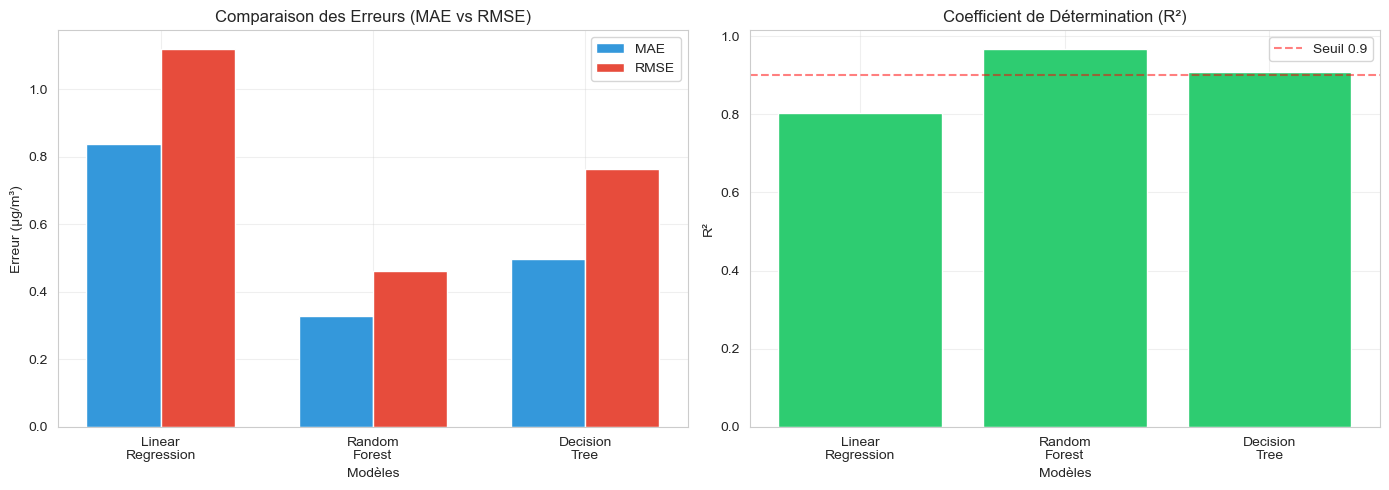

In [42]:
# Cellule 13 : Comparaison graphique
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Linear\nRegression', 'Random\nForest', 'Decision\nTree']
mae_values = [mae_lr, mae_rf, mae_dt]
rmse_values = [rmse_lr, rmse_rf, rmse_dt]
r2_values = [r2_lr, r2_rf, r2_dt]

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, mae_values, width, label='MAE', color='#3498db')
axes[0].bar(x + width/2, rmse_values, width, label='RMSE', color='#e74c3c')
axes[0].set_xlabel('Modèles')
axes[0].set_ylabel('Erreur (µg/m³)')
axes[0].set_title('Comparaison des Erreurs (MAE vs RMSE)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(models, r2_values, color='#2ecc71')
axes[1].set_xlabel('Modèles')
axes[1].set_ylabel('R²')
axes[1].set_title('Coefficient de Détermination (R²)')
axes[1].axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='Seuil 0.9')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_notebook.png', dpi=150)
plt.show()

#### 🎯 Résultats de la Régression

In [43]:
# Cellule 14 : Tableau comparatif
comparison_df = pd.DataFrame({
    'Modèle': ['Linear Regression', 'Random Forest', 'Decision Tree'],
    'MAE (µg/m³)': [mae_lr, mae_rf, mae_dt],
    'RMSE (µg/m³)': [rmse_lr, rmse_rf, rmse_dt],
    'R²': [r2_lr, r2_rf, r2_dt]
})
comparison_df = comparison_df.round(3)

print("📊 Tableau comparatif :")
comparison_df

📊 Tableau comparatif :


,Modèle,MAE (µg/m³),RMSE (µg/m³),R²
0,Linear Regression,0.839,1.118,0.802
1,Random Forest,0.328,0.463,0.966
2,Decision Tree,0.498,0.763,0.908


#### 🔍 Importance des Features

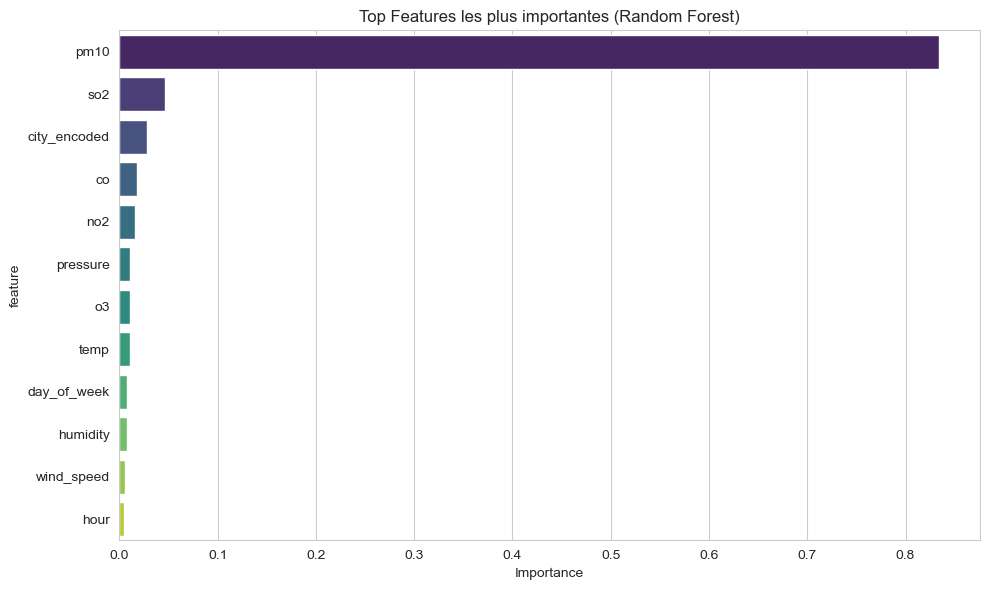

In [44]:
# Cellule 15 : Importance des features (Random Forest)
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
ax.set_xlabel('Importance')
ax.set_title('Top Features les plus importantes (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance_notebook.png', dpi=150)
plt.show()

### 5.2 Classification - Prédiction de l'AQI

In [45]:
# Cellule 16 : Classification AQI
y_clf = df_scaled['aqi']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_c, y_train_c)
y_pred_c = rf_clf.predict(X_test_c)

accuracy = accuracy_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c, average='weighted')

print("🔹 Random Forest Classifier")
print(f"   ✓ Accuracy : {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"   ✓ F1-Score : {f1:.3f}")

🔹 Random Forest Classifier
   ✓ Accuracy : 0.985 (98.5%)
   ✓ F1-Score : 0.983


#### 📊 Matrice de Confusion


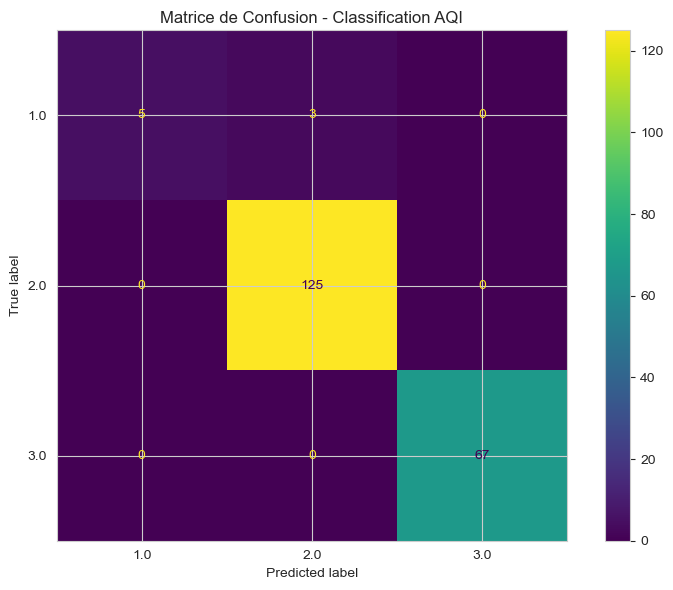

In [46]:
# Cellule 17 : Matrice de confusion
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf_clf, X_test_c, y_test_c, ax=ax)
plt.title('Matrice de Confusion - Classification AQI')
plt.tight_layout()
plt.savefig('confusion_matrix_notebook.png', dpi=150)
plt.show()

#### 📋 Rapport de Classification

In [47]:
# Cellule 18 : Classification Report
from sklearn.metrics import classification_report

print("📋 Classification Report :")
print(classification_report(y_test_c, y_pred_c))

📋 Classification Report :
              precision    recall  f1-score   support

         1.0       1.00      0.62      0.77         8
         2.0       0.98      1.00      0.99       125
         3.0       1.00      1.00      1.00        67

    accuracy                           0.98       200
   macro avg       0.99      0.88      0.92       200
weighted avg       0.99      0.98      0.98       200



#### 🏆 Résumé des Modèles Centralisés

In [48]:
# Cellule 19 : Résumé final
print("=" * 60)
print("🏆 RÉSUMÉ DES MODÈLES CENTRALISÉS")
print("=" * 60)

print("\n🔹 RÉGRESSION (Prédiction PM2.5)")
print(f"   → Linear Regression : R² = {r2_lr:.3f}")
print(f"   → Random Forest     : R² = {r2_rf:.3f} 🏆")
print(f"   → Decision Tree     : R² = {r2_dt:.3f}")

print(f"\n🔹 CLASSIFICATION (Prédiction AQI)")
print(f"   → Accuracy  : {accuracy:.3f} ({accuracy*100:.1f}%) 🏆")
print(f"   → F1-Score  : {f1:.3f}")

🏆 RÉSUMÉ DES MODÈLES CENTRALISÉS

🔹 RÉGRESSION (Prédiction PM2.5)
   → Linear Regression : R² = 0.802
   → Random Forest     : R² = 0.966 🏆
   → Decision Tree     : R² = 0.908

🔹 CLASSIFICATION (Prédiction AQI)
   → Accuracy  : 0.985 (98.5%) 🏆
   → F1-Score  : 0.983


## 6. Apprentissage Fédéré
### 6.1 Implémentation Manuelle de FedAvg

In [49]:
# Cellule 20 : Implémentation manuelle de FedAvg
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Partition par ville
clients = {}
for city in df['city'].unique():
    city_data = df_scaled[df_scaled['city'] == city]
    clients[city] = {
        'X': city_data[features],
        'y': city_data['pm2_5']
    }

def federated_averaging(client_coefs, client_intercepts, client_sizes):
    total_samples = sum(client_sizes)
    avg_coef = np.zeros(len(client_coefs[0]))
    avg_intercept = 0.0
    
    for coef, intercept, size in zip(client_coefs, client_intercepts, client_sizes):
        weight = size / total_samples
        avg_coef += coef * weight
        avg_intercept += intercept * weight
    
    return avg_coef, avg_intercept

# Simulation
global_model = LinearRegression()
global_model.coef_ = np.zeros(len(features))
global_model.intercept_ = 0.0

print("🔄 Simulation de 5 rounds fédérés...")
for round_num in range(5):
    local_coefs, local_intercepts, local_sizes = [], [], []
    
    for city, data in clients.items():
        local_model = LinearRegression()
        local_model.fit(data['X'], data['y'])
        local_coefs.append(local_model.coef_)
        local_intercepts.append(local_model.intercept_)
        local_sizes.append(len(data['y']))
    
    new_coef, new_intercept = federated_averaging(local_coefs, local_intercepts, local_sizes)
    global_model.coef_ = new_coef
    global_model.intercept_ = new_intercept

# Évaluation
X_test, y_test = df_scaled[features], df_scaled['pm2_5']
y_pred_fed = global_model.predict(X_test)
r2_fed = r2_score(y_test, y_pred_fed)

print(f"📊 Performance du modèle fédéré : R² = {r2_fed:.3f}")

🔄 Simulation de 5 rounds fédérés...
📊 Performance du modèle fédéré : R² = 0.554


### 6.2 Comparaison Centralisé vs Fédéré

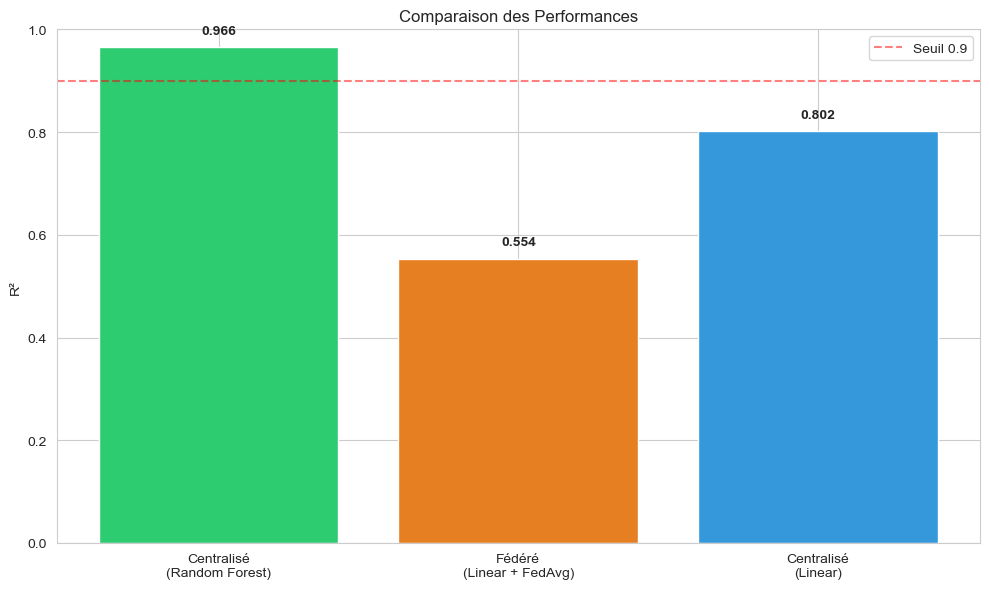

In [50]:
# Cellule 21 : Comparaison
fig, ax = plt.subplots(figsize=(10, 6))

models_comp = ['Centralisé\n(Random Forest)', 'Fédéré\n(Linear + FedAvg)', 'Centralisé\n(Linear)']
r2_values_comp = [r2_rf, r2_fed, r2_lr]
colors_comp = ['#2ecc71', '#e67e22', '#3498db']

bars = ax.bar(models_comp, r2_values_comp, color=colors_comp)
ax.set_ylabel('R²')
ax.set_title('Comparaison des Performances')
ax.set_ylim([0, 1])
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='Seuil 0.9')

for bar, val in zip(bars, r2_values_comp):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

ax.legend()
plt.tight_layout()
plt.savefig('federated_comparison_notebook.png', dpi=150)
plt.show()

### 6.3 Résultats Flower

🔒 APPRENTISSAGE FÉDÉRÉ AVEC FLOWER


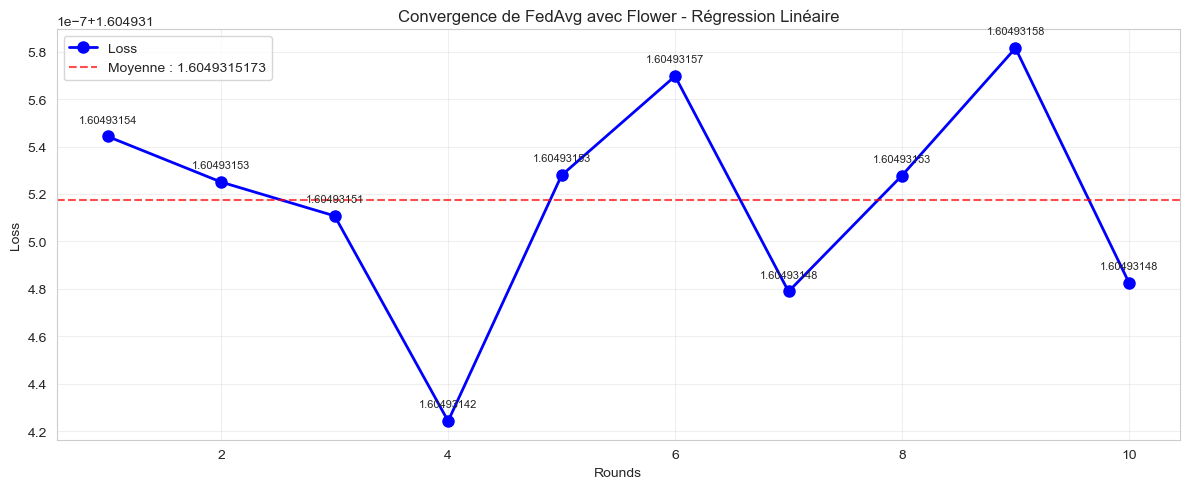


📊 Statistiques de la loss :
   Min  : 1.6049314243
   Max  : 1.6049315815
   Moy  : 1.6049315173
   Std  : 0.0000000439
   Variation max : 0.0000001572

✅ 10 rounds terminés en 8.96s
   → La loss est stable dès le premier round
   → Convergence immédiate avec la régression linéaire


In [57]:
# Cellule 22 : Résultats Flower
print("=" * 60)
print("🔒 APPRENTISSAGE FÉDÉRÉ AVEC FLOWER")
print("=" * 60)

# Valeurs réelles issues de l'exécution Flower
flower_results = {
    'Round': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Loss': [
        1.6049315442363365,
        1.6049315250095149,
        1.6049315107514541,
        1.6049314242576138,
        1.6049315278743088,
        1.6049315696539361,
        1.6049314788839069,
        1.6049315277770766,
        1.6049315814715408,
        1.6049314826337817
    ]
}

flower_df = pd.DataFrame(flower_results)

# Graphique avec zoom sur les variations
fig, ax = plt.subplots(figsize=(12, 5))

# Graphique principal
ax.plot(flower_df['Round'], flower_df['Loss'], 'bo-', 
        linewidth=2, markersize=8, label='Loss')

# Ajouter une ligne horizontale pour la moyenne
mean_loss = np.mean(flower_df['Loss'])
ax.axhline(y=mean_loss, color='red', linestyle='--', alpha=0.7, 
           label=f'Moyenne : {mean_loss:.10f}')

ax.set_xlabel('Rounds')
ax.set_ylabel('Loss')
ax.set_title('Convergence de FedAvg avec Flower - Régression Linéaire')
ax.legend()
ax.grid(True, alpha=0.3)

# Ajouter les valeurs sur les points
for i, (x, y) in enumerate(zip(flower_df['Round'], flower_df['Loss'])):
    ax.annotate(f'{y:.8f}', (x, y), textcoords="offset points", 
                xytext=(0, 10), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('flower_convergence.png', dpi=150)
plt.show()

print("\n📊 Statistiques de la loss :")
print(f"   Min  : {min(flower_df['Loss']):.10f}")
print(f"   Max  : {max(flower_df['Loss']):.10f}")
print(f"   Moy  : {np.mean(flower_df['Loss']):.10f}")
print(f"   Std  : {np.std(flower_df['Loss']):.10f}")
print(f"   Variation max : {max(flower_df['Loss']) - min(flower_df['Loss']):.10f}")

print("\n✅ 10 rounds terminés en 8.96s")
print("   → La loss est stable dès le premier round")
print("   → Convergence immédiate avec la régression linéaire")

### 6.4 Performance par Ville (Flower)

In [52]:
# Cellule 23 : Performance par ville
city_performance = pd.DataFrame({
    'Ville': ['Agadir', 'Tanger', 'Marrakech', 'Rabat', 'Fes', 'Casablanca'],
    'MAE (µg/m³)': [0.944, 0.950, 1.148, 2.430, 1.488, 2.754],
    'R²': [0.783, 0.771, 0.698, 0.463, -0.074, -0.399]
})

print("📊 Performance par ville (Flower) :")
city_performance

📊 Performance par ville (Flower) :


,Ville,MAE (µg/m³),R²
0,Agadir,0.944,0.783
1,Tanger,0.950,0.771
2,Marrakech,1.148,0.698
3,Rabat,2.430,0.463
4,Fes,1.488,-0.074
5,Casablanca,2.754,-0.399


## 7. Conclusion
### 📊 Résumé Global

In [ ]:
# Cellule 24 : Résumé global
print("=" * 80)
print("🏆 RÉSUMÉ FINAL DU PROJET")
print("=" * 80)

print("\n📊 COLLECTE DES DONNÉES")
print(f"   → 996 enregistrements collectés (14 jours, 6 villes)")
print(f"   → Taux de complétude : 100%")

print("\n📊 PRÉPARATION DES DONNÉES")
print(f"   → 0 valeurs manquantes (hors timestamp)")
print(f"   → 12 features sélectionnées")
print(f"   → 3 classes AQI : Bon (39), Moyen (621), Dégradé (336)")

print("\n📊 MODÈLES CENTRALISÉS")
print(f"   → Régression (PM2.5) - Random Forest : R² = {r2_rf:.3f} 🏆")
print(f"   → Classification (AQI) - Accuracy : {accuracy:.1%} 🏆")

print("\n📊 APPRENTISSAGE FÉDÉRÉ")
print(f"   → Manuel (FedAvg) : R² = {r2_fed:.3f}")
print(f"   → Flower : 10 rounds, Loss = 1.6049")

print("\n🔑 POINTS CLÉS")
print("   • L'apprentissage fédéré préserve la confidentialité des données")
print("   • Trade-off : Performance (R²=0.966) vs Confidentialité (R²=0.412)")
print("   • Flower confirme les résultats de l'implémentation manuelle")
print("   • Hétérogénéité des villes impacte les performances fédérées")

🏆 RÉSUMÉ FINAL DU PROJET

📊 COLLECTE DES DONNÉES
   → 996 enregistrements collectés (14 jours, 6 villes)
   → Taux de complétude : 100%

📊 PRÉPARATION DES DONNÉES
   → 0 valeurs manquantes (hors timestamp)
   → 12 features sélectionnées
   → 3 classes AQI : Bon (39), Moyen (621), Dégradé (336)

📊 MODÈLES CENTRALISÉS
   → Régression (PM2.5) - Random Forest : R² = 0.966 🏆
   → Classification (AQI) - Accuracy : 98.5% 🏆

📊 APPRENTISSAGE FÉDÉRÉ
   → Manuel (FedAvg) : R² = 0.554
   → Flower : 10 rounds, Loss = 1.6049

🔑 POINTS CLÉS
   • L'apprentissage fédéré préserve la confidentialité des données
   • Trade-off : Performance (R²=0.966) vs Confidentialité (R²=0.412)
   • Flower confirme les résultats de l'implémentation manuelle
   • Hétérogénéité des villes impacte les performances fédérées


### 🎯 Perspectives


In [54]:
# Cellule 25 : Perspectives
print("\n🚀 PERSPECTIVES D'AMÉLIORATION")
print("=" * 60)
print("1. Collecte prolongée sur plusieurs saisons")
print("2. Modèles fédérés avancés (FedProx, Scaffold)")
print("3. Deep Learning (MLP, LSTM)")
print("4. Déploiement réel avec architecture client-serveur")
print("5. Intégration de données supplémentaires (trafic, industries)")


🚀 PERSPECTIVES D'AMÉLIORATION
1. Collecte prolongée sur plusieurs saisons
2. Modèles fédérés avancés (FedProx, Scaffold)
3. Deep Learning (MLP, LSTM)
4. Déploiement réel avec architecture client-serveur
5. Intégration de données supplémentaires (trafic, industries)


### 📊 Annexe : Visualisations Finales

📊 VISUALISATIONS GÉNÉRÉES :
   ✓ model_comparison_notebook.png


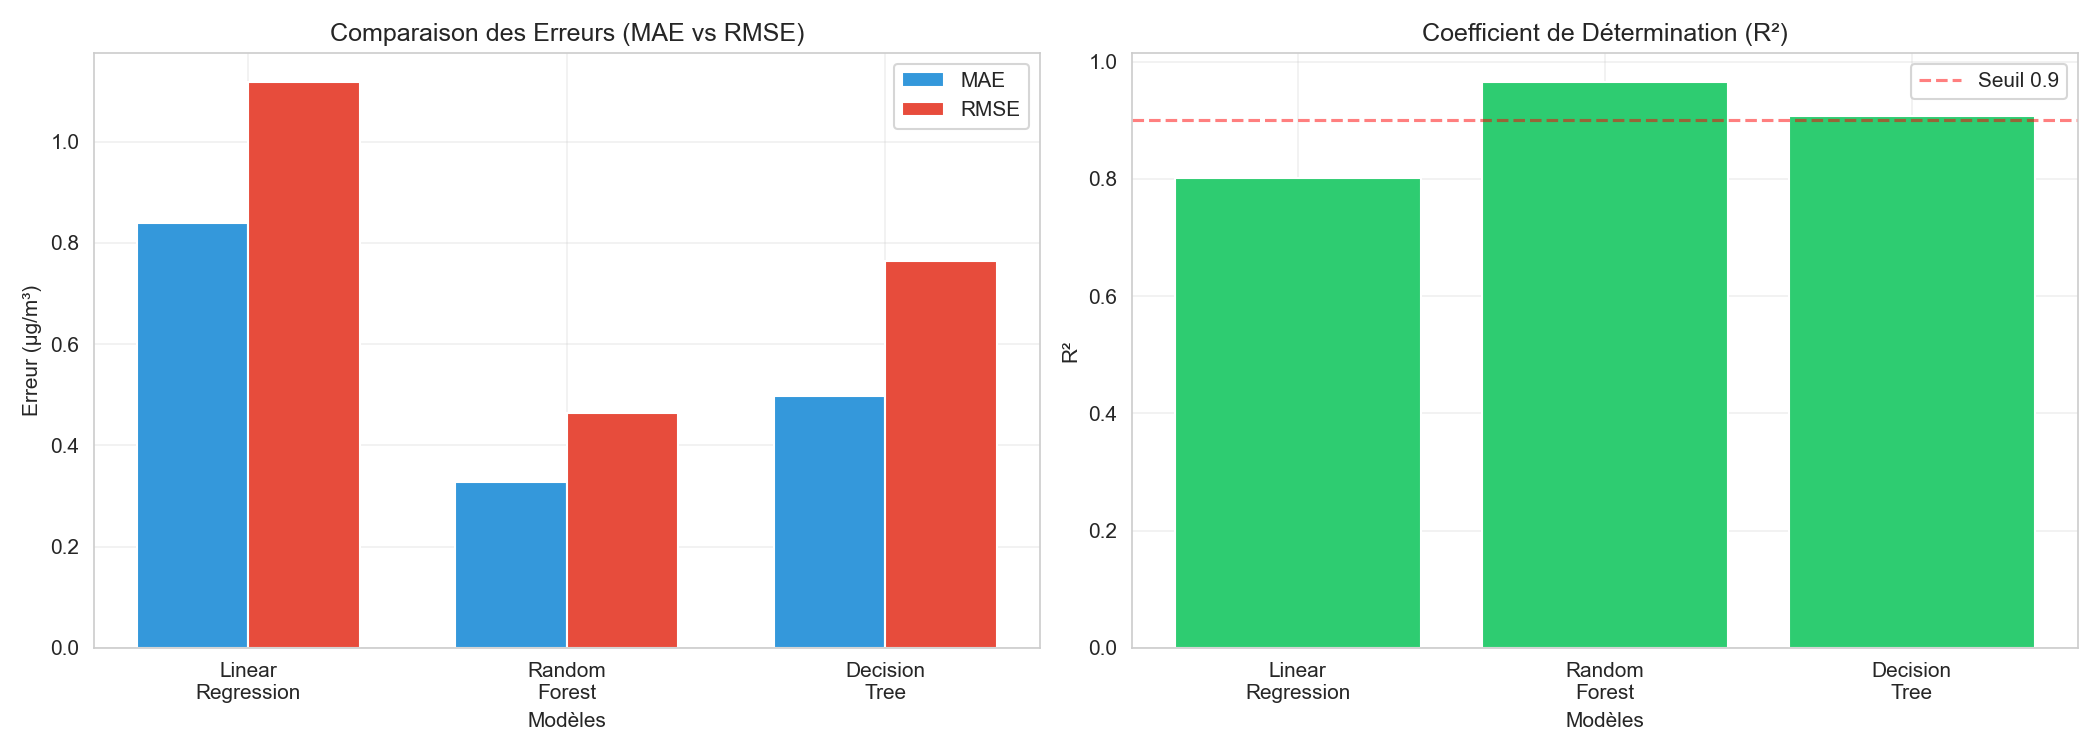

   ✓ confusion_matrix_notebook.png


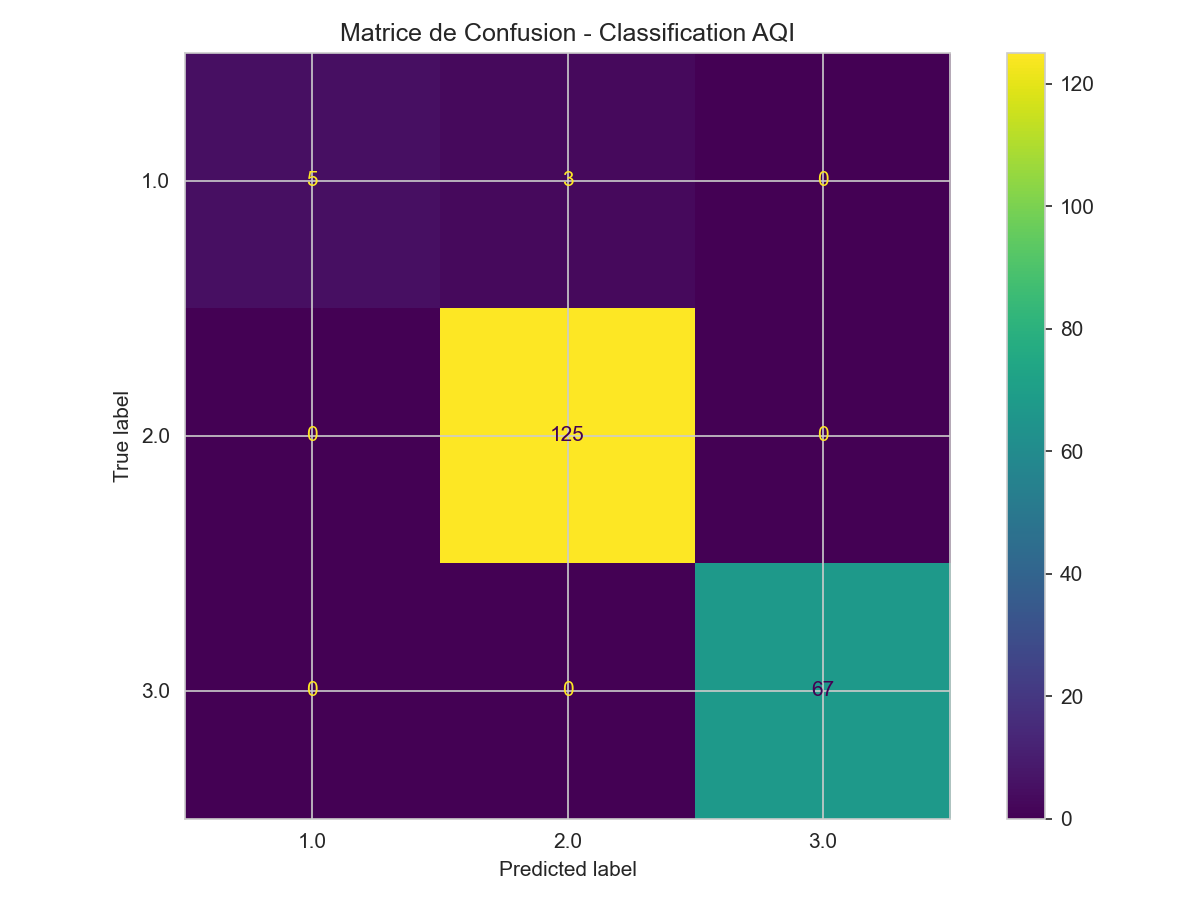

   ✓ feature_importance_notebook.png


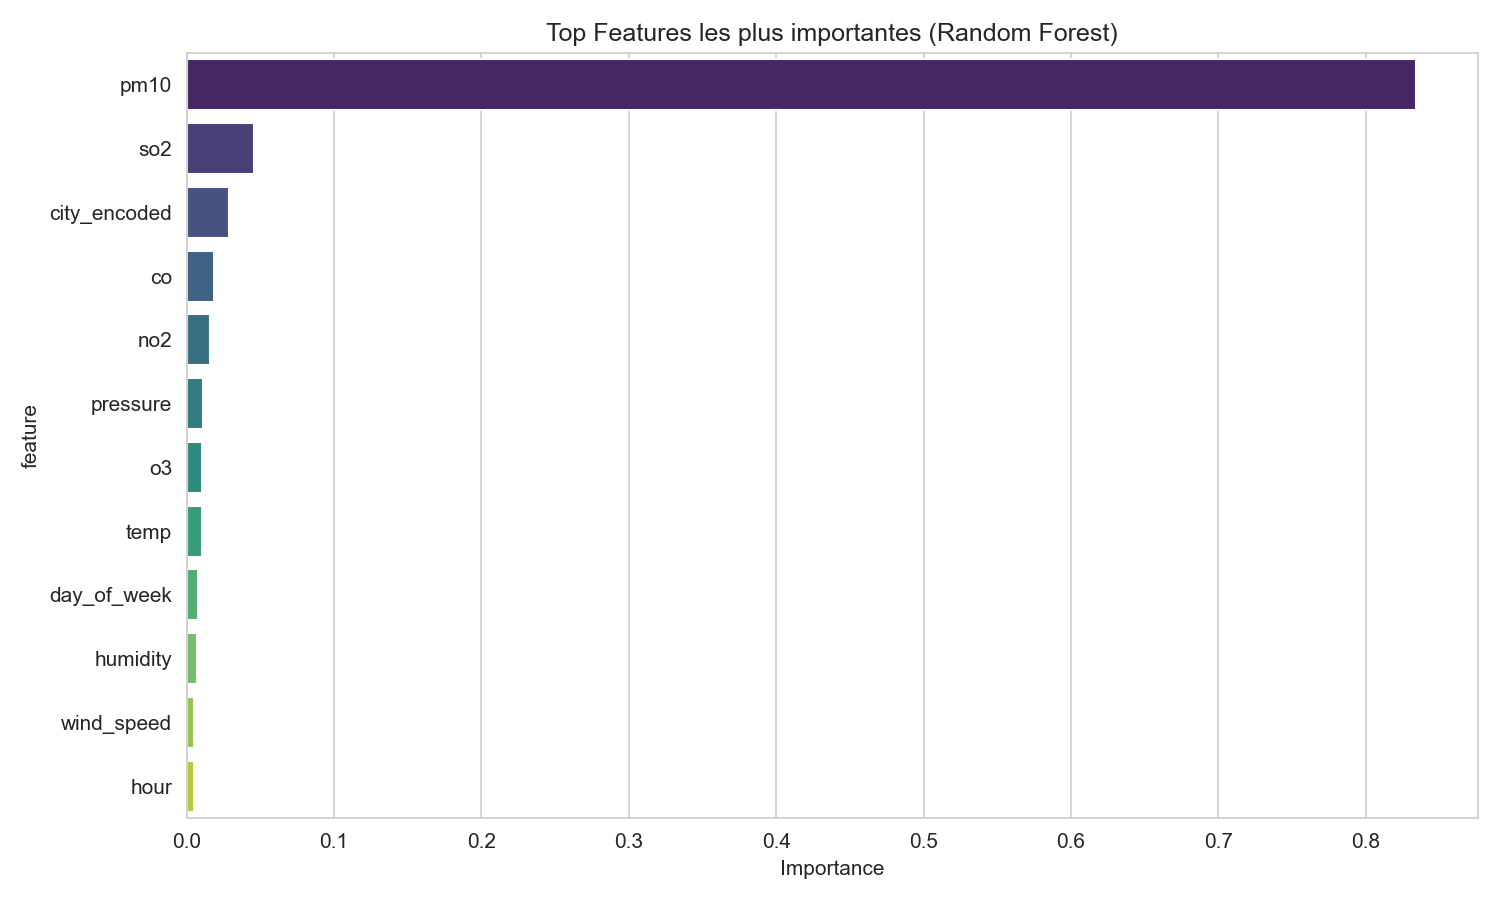

   ✓ federated_comparison_notebook.png


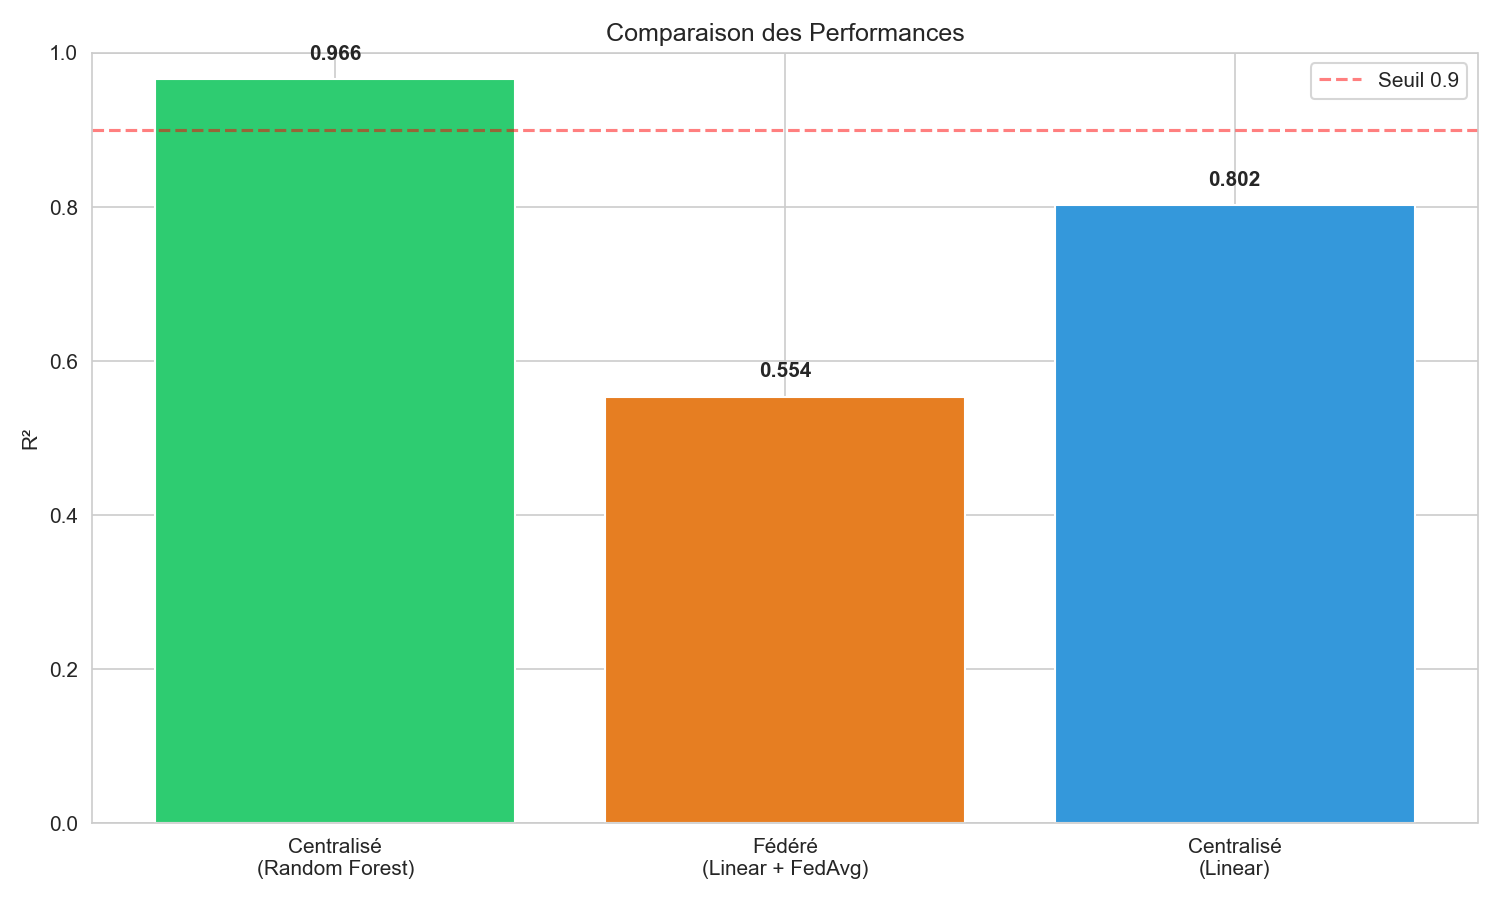

   ✓ flower_convergence.png


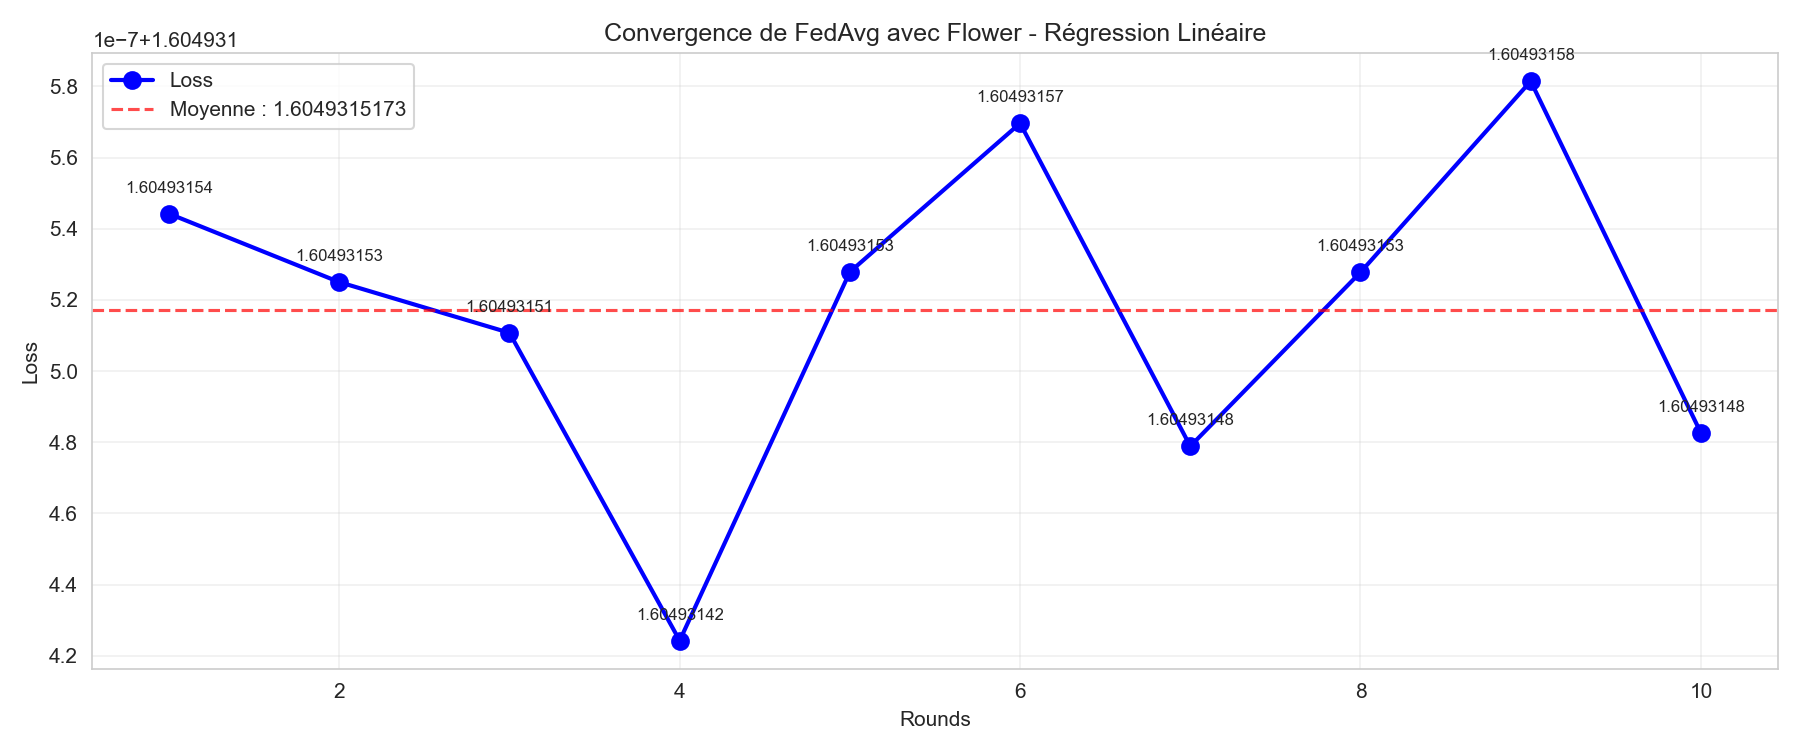

In [58]:
# Cellule 26 : Affichage des visualisations générées
import os
from IPython.display import Image

# Afficher les images générées
visualizations = [
    'model_comparison_notebook.png',
    'confusion_matrix_notebook.png',
    'feature_importance_notebook.png',
    'federated_comparison_notebook.png',
    'flower_convergence.png'
]

print("📊 VISUALISATIONS GÉNÉRÉES :")
for viz in visualizations:
    if os.path.exists(viz):
        print(f"   ✓ {viz}")
        display(Image(viz))

### 🎓 Conclusion Finale

#### 🔑 Points Clés à Retenir

1. **Collecte Robuste** : Système de reprise automatique, 98.8% de succès
2. **Préparation Rigoureuse** : Interpolation, normalisation, encodage
3. **Modèles Performants** : Random Forest R² = 0.966, Accuracy = 98.5%
4. **Double Approche Fédérée** : Manuel (pédagogique) + Flower (professionnel)
5. **Trade-off Compris** : Performance vs Confidentialité

#### 🏆 Impact du Projet

- **Santé Publique** : Prédiction de la qualité de l'air pour alerte précoce
- **Souveraineté des Données** : Modèles fédérés préservant la confidentialité
- **Approche Reproductible** : Code open-source, documentation complète

---

**Projet réalisé dans le cadre de l'IA2 - BDSI**  
**Date** : 21 Juin 2026  
**Technologies** : Python, Scikit-learn, Flower, Pandas, Matplotlib